## データの前処理

In [27]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 回転とリサイズ
affine = transforms.RandomAffine([-30, 30], scale=(0.8, 1.2))
# シフト
shift = transforms.RandomAffine((0, 0), translate=(0.5, 0.5))
# 左右反転
flip = transforms.RandomHorizontalFlip(p=0.5)
# 一部を消去
erasing = transforms.RandomErasing(p=0.5)
# 平均値を0, 標準偏差を1にする
normalize = transforms.Normalize((0.0, 0.0, 0.0), (1.0, 1.0, 1.0))
to_tensor = transforms.ToTensor()

# ノイズなしの訓練データ
transform_train = transforms.Compose([to_tensor, normalize])
# 一部消去した訓練データ
transform_train_erasing = transforms.Compose([to_tensor, erasing, normalize])
# 複数のノイズをランダムで与えた訓練データ
transform_train_random = transforms.Compose([
    transforms.RandomApply([affine], p=0.5),
    transforms.RandomApply([shift], p=0.5),
    transforms.RandomApply([flip], p=0.5),
    to_tensor,
    transforms.RandomApply([erasing], p=0.5),
    normalize,
])

transform_test = transforms.Compose([to_tensor, normalize])
cifar10_train = CIFAR10("./data", train=True, download=True, transform=transform_train)
cifar10_train_erasing = CIFAR10("./data", train=True, download=True, transform=transform_train_erasing)
cifar10_train_random = CIFAR10("./data", train=True, download=True, transform=transform_train_random)
cifar10_test = CIFAR10("./data", train=False, download=True, transform=transform_test)

# DataLoaderの設定
batch_size = 64
train_loader = DataLoader(cifar10_train, batch_size=batch_size, shuffle=True)
train_loader_erasing = DataLoader(cifar10_train_erasing, batch_size=batch_size, shuffle=True)
train_loader_random = DataLoader(cifar10_train_random, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(cifar10_test, batch_size=batch_size, shuffle=False)

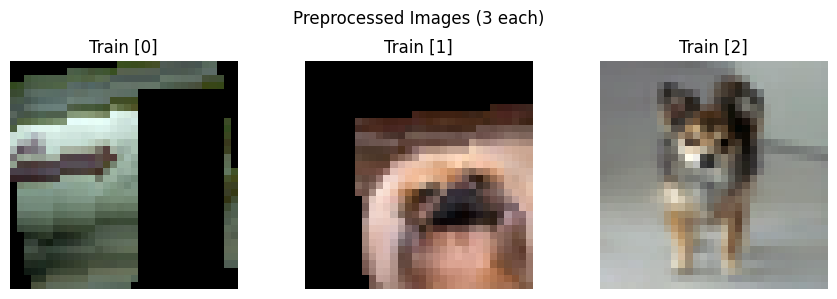

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for i in range(3):
    img = next(iter(train_loader_random))[0][i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    axes[i].imshow(img)
    axes[i].set_title(f"Train [{i}]")
    axes[i].axis('off')

plt.suptitle("Preprocessed Images (3 each)")
plt.tight_layout()
plt.show()


## グラフ描画関数と学習率計算関数を定義

In [17]:
import matplotlib.pyplot as plt

def plot_loss_curve(record_loss_train, record_loss_test):
    plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
    plt.plot(range(len(record_loss_test)), record_loss_test, label="Test")
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel("Error")
    plt.show()

def calculate_accuracy(net, data_loader, device="cuda"):
    correct = 0
    total = 0
    net.eval()
    for _, (x, t) in enumerate(data_loader):
        x, t = x.to(device), t.to(device)
        y = net(x)
        correct += (y.argmax(1) == t).sum().item()
        total += len(x)
    return correct / total * 100



## ベースライン③
- 複数のノイズをランダムで与えたデータセットで学習
- モデルはベースライン①と同じ
- 20エポック  
**→データセットが膨大なため、エポック数が足りなかった？**

In [14]:
import torch.nn as nn

class Net1(nn.Module):
    def __init__(self):
        super().__init__()
        # 畳み込み層（入力チャンネル数、フィルタ数、フィルタサイズ）
        self.conv1 = nn.Conv2d(3, 6, 5)
        # 活性化関数ReLU
        self.relu = nn.ReLU()
        # プーリング層（領域のサイズ、領域の感覚）
        self.pool = nn.MaxPool2d(2, 2)
        # 畳み込み層
        self.conv2 = nn.Conv2d(6, 16, 5)
        # 全結合層
        self.fc1 = nn.Linear(16*5*5, 256)
        # ドロップアウト（ドロップアウト率）
        self.dropout = nn.Dropout(p=0.5)
        # 全結合層
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 16*5*5)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x
    


Net1(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [16]:
# net初期化
net = Net1()
net.cuda() # GPU対応

from torch import optim

# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
x_test, t_test = next(iter(test_loader))
x_test, t_test = x_test.cuda(), t_test.cuda()
for i in range(20): # 20エポック学習
    net.train() # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader_random): # ミニバッチ（x, t)を取り出す
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()    # パラメータの更新
    loss_train /= j+1   # 平均値をとる
    record_loss_train.append(loss_train)

    # 評価モード
    net.eval()
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)
        

Epoch: 0 Loss_Train: 2.012104422997331 Loss_Test: 1.6611563476027957
Epoch: 1 Loss_Train: 1.8338364698088077 Loss_Test: 1.5529288083884367
Epoch: 2 Loss_Train: 1.7748510322302504 Loss_Test: 1.4763999182707186
Epoch: 3 Loss_Train: 1.7439560458788177 Loss_Test: 1.467217829576723
Epoch: 4 Loss_Train: 1.7200846701022 Loss_Test: 1.4240193161994787
Epoch: 5 Loss_Train: 1.7041449664193955 Loss_Test: 1.3932724652017
Epoch: 6 Loss_Train: 1.687321985469145 Loss_Test: 1.3693216196291007
Epoch: 7 Loss_Train: 1.6768999779620744 Loss_Test: 1.3253487424486001
Epoch: 8 Loss_Train: 1.6702103000467696 Loss_Test: 1.335502576676144
Epoch: 9 Loss_Train: 1.6562653892790264 Loss_Test: 1.3112128669289267
Epoch: 10 Loss_Train: 1.6490197853968882 Loss_Test: 1.3030809277941466
Epoch: 11 Loss_Train: 1.6351259430046277 Loss_Test: 1.3158001577018932
Epoch: 12 Loss_Train: 1.6347415954865459 Loss_Test: 1.3166737009765237
Epoch: 13 Loss_Train: 1.627208891274679 Loss_Test: 1.2409209931731984
Epoch: 14 Loss_Train: 1.617

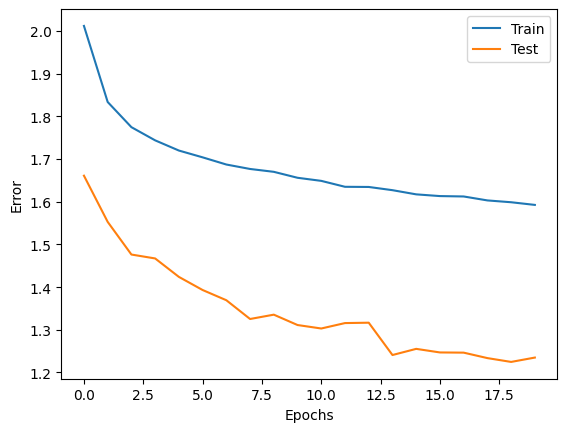

正解率:  55.42%


In [18]:
# 結果出力
plot_loss_curve(record_loss_train, record_loss_test)
accuracy = calculate_accuracy(net, test_loader)
print("正解率: ", str(accuracy) + "%")

## ベースライン④
- ベースライン③と同条件で、エポック数を40  
→精度はあまり変わらなかった

In [19]:
# net初期化
net = Net1()
net.cuda() # GPU対応

from torch import optim

# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
x_test, t_test = next(iter(test_loader))
x_test, t_test = x_test.cuda(), t_test.cuda()
for i in range(40): # 40エポック学習
    net.train() # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader_random): # ミニバッチ（x, t)を取り出す
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()    # パラメータの更新
    loss_train /= j+1   # 平均値をとる
    record_loss_train.append(loss_train)

    # 評価モード
    net.eval()
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)
        

Epoch: 0 Loss_Train: 2.029066352130812 Loss_Test: 1.7280553100974696
Epoch: 1 Loss_Train: 1.9002195357361717 Loss_Test: 1.5989484878102684
Epoch: 2 Loss_Train: 1.8392194485115578 Loss_Test: 1.5204112863844368
Epoch: 3 Loss_Train: 1.793973878064119 Loss_Test: 1.5014299700973899
Epoch: 4 Loss_Train: 1.766635468853709 Loss_Test: 1.5243525740447317
Epoch: 5 Loss_Train: 1.7522080510168734 Loss_Test: 1.4366509800503968
Epoch: 6 Loss_Train: 1.7330793535617917 Loss_Test: 1.3970203688190241
Epoch: 7 Loss_Train: 1.7214246838903793 Loss_Test: 1.3824335374649923
Epoch: 8 Loss_Train: 1.7104123782013994 Loss_Test: 1.3926155681063415
Epoch: 9 Loss_Train: 1.7029881279181946 Loss_Test: 1.3432340811771952
Epoch: 10 Loss_Train: 1.6934184921367088 Loss_Test: 1.3635364710145694
Epoch: 11 Loss_Train: 1.675107092961021 Loss_Test: 1.3418653800988654
Epoch: 12 Loss_Train: 1.6686361067740203 Loss_Test: 1.3361164961650873
Epoch: 13 Loss_Train: 1.6642610441388377 Loss_Test: 1.317442152150877
Epoch: 14 Loss_Train:

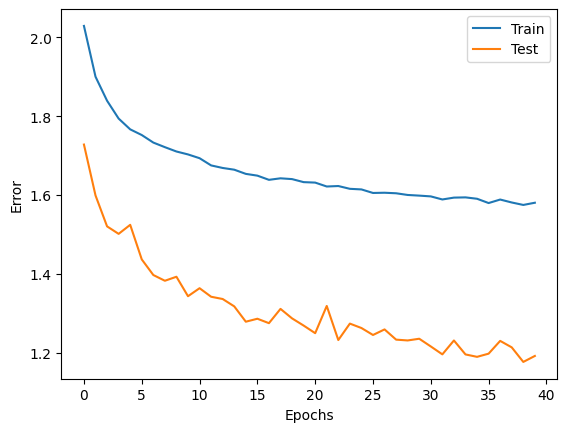

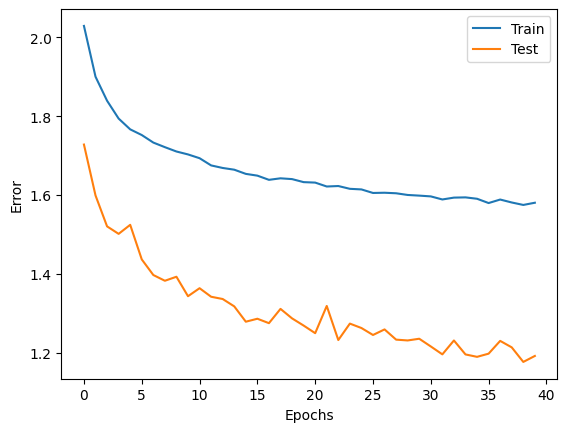

正解率:  57.26%


In [20]:
# 結果出力
plot_loss_curve(record_loss_train, record_loss_test)
accuracy = calculate_accuracy(net, test_loader)
print("正解率: ", str(accuracy) + "%")

## モデル検討③
- 複数のノイズをランダムで与えたデータセットで学習
- 40エポック
- Net2

In [26]:
import torch.nn as nn

class Net2(nn.Module):
    def __init__(self):
        super().__init__()
        # 畳み込み層（入力チャンネル数、フィルタ数、フィルタサイズ）
        self.conv1 = nn.Conv2d(3, 32, 3)     # フィルタ数6->32、フィルタサイズ5->3
        self.conv2 = nn.Conv2d(32, 64, 3)        # フィルタ数16->64、フィルタサイズを5->3

        # 活性化関数ReLU
        self.relu = nn.ReLU()

        # プーリング層（領域のサイズ、領域の感覚）
        self.pool = nn.MaxPool2d(2, 2)
        
        # 全結合層
        self.fc1 = nn.Linear(64*6*6, 256)

        # ドロップアウト（ドロップアウト率）
        self.dropout = nn.Dropout(p=0.5)

        # 全結合層
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)
        
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [28]:
# net初期化
net = Net2()
net.cuda() # GPU対応


# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
x_test, t_test = next(iter(test_loader))
x_test, t_test = x_test.cuda(), t_test.cuda()
for i in range(40): # 40エポック学習
    net.train() # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader_random): # ミニバッチ（x, t)を取り出す
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()    # パラメータの更新
    loss_train /= j+1   # 平均値をとる
    record_loss_train.append(loss_train)

    # 評価モード
    net.eval()
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)
        

Epoch: 0 Loss_Train: 1.9227487926592912 Loss_Test: 1.5411583823003587
Epoch: 1 Loss_Train: 1.7206109624994381 Loss_Test: 1.372249033041061
Epoch: 2 Loss_Train: 1.6363170912198703 Loss_Test: 1.3004524320553823
Epoch: 3 Loss_Train: 1.5969657989414148 Loss_Test: 1.209756368284772
Epoch: 4 Loss_Train: 1.5544625907907705 Loss_Test: 1.1651590842350272
Epoch: 5 Loss_Train: 1.522422387167011 Loss_Test: 1.1275099288126467
Epoch: 6 Loss_Train: 1.505651004631501 Loss_Test: 1.0854662770678283
Epoch: 7 Loss_Train: 1.4842762722993446 Loss_Test: 1.0725324989124467
Epoch: 8 Loss_Train: 1.4604353352885722 Loss_Test: 1.0733158850366142
Epoch: 9 Loss_Train: 1.447111405984825 Loss_Test: 1.0249053794107619
Epoch: 10 Loss_Train: 1.4378160192533527 Loss_Test: 1.018043760661107
Epoch: 11 Loss_Train: 1.427145430041701 Loss_Test: 1.0466116606050235
Epoch: 12 Loss_Train: 1.417479216290252 Loss_Test: 0.9958240211389626
Epoch: 13 Loss_Train: 1.3995332779634335 Loss_Test: 1.0312095694481187
Epoch: 14 Loss_Train: 1.

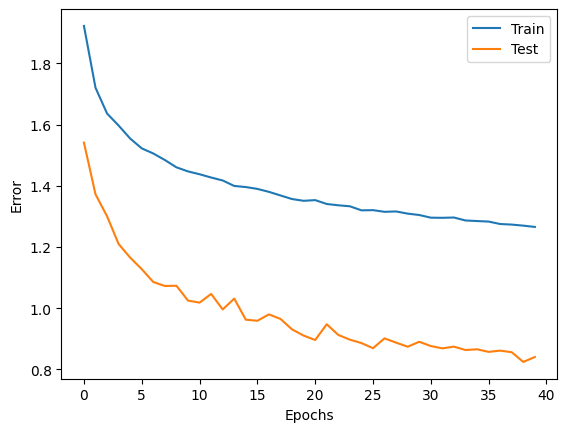

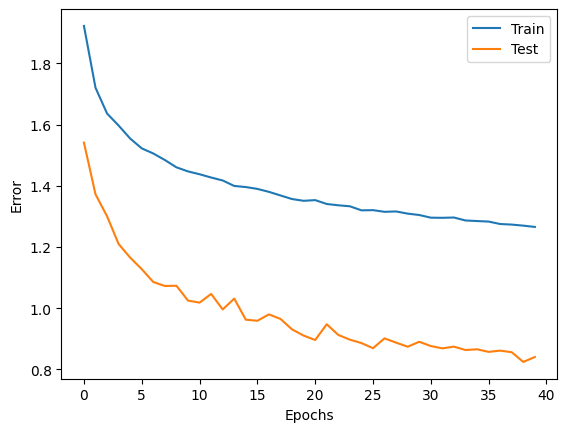

正解率:  71.02000000000001%


In [29]:
# 結果出力
plot_loss_curve(record_loss_train, record_loss_test)
accuracy = calculate_accuracy(net, test_loader)
print("正解率: ", str(accuracy) + "%")

## モデル検討④
- 

In [ ]:
import torch.nn as nn

class Net3(nn.Module):
    def __init__(self):
        super().__init__()
        # 畳み込み層（入力チャンネル数、フィルタ数、フィルタサイズ）
        self.conv1 = nn.Conv2d(3, 32, 3)     # フィルタ数6->32、フィルタサイズ5->3
        self.conv2 = nn.Conv2d(32, 64, 3)        # フィルタ数16->64、フィルタサイズを5->3

        # 活性化関数ReLU
        self.relu = nn.ReLU()

        # プーリング層（領域のサイズ、領域の感覚）
        self.pool = nn.MaxPool2d(2, 2)
        
        # 全結合層
        self.fc1 = nn.Linear(64*6*6, 256)

        # ドロップアウト（ドロップアウト率）
        self.dropout = nn.Dropout(p=0.5)

        # 全結合層
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)
        
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## 実験結果まとめ

| 実験 | データ条件 | モデル条件 | エポック数 | 正解率 |
|---|---|---|---:|---:|
| ベースライン① | ノイズなし訓練データ（正規化のみ） | CNN（Conv: 3→6→16, カーネル5x5, FC: 16x5x5→256→10） | 20 | 61.97% |
| ベースライン② | 一部消去あり訓練データ（RandomErasing + 正規化） | ベースライン①と同一 | 20 | 60.69% |
| ベースライン③ | 複数ノイズをランダム付与した訓練データ | ベースライン①と同一 | 20 | 55.42% |
| ベースライン④ | 複数ノイズをランダム付与した訓練データ | ベースライン①と同一 | 40 | 57.26% |
| モデル検討① | 一部消去あり訓練データ | CNN改良（Conv: 3→32→64, カーネル3x3, FC: 64x6x6→256→10） | 20 | 71.21% |
| モデル検討② | 一部消去あり訓練データ | CNN改良（Conv: 3→32→64→128, プーリング回数増加, FC: 128x2x2→256→10） | 20 | 70.91% |
| モデル検討③ | 複数ノイズをランダム付与した訓練データ | CNN改良（Conv: 3→32→64, カーネル3x3, FC: 64x6x6→256→10） | 40 | 71.02% |
| モデル検討④ | 複数ノイズをランダム付与した訓練データ | CNN改良（Conv: 3→32→64→128, プーリング回数増加, FC: 128x2x2→256→10） | 20 | 68.90% |